# Methods for phase extraction from respiration data

In [ ]:
import numpy as np
from pyriodic.preproc import RawSignal
from pyriodic.viz import plot_phase_diagnostics

import matplotlib.pyplot as plt


In [15]:
# load data
from bioread import read_file
data = read_file("../../data/respiration/example.acq")

# extract respiration channel and sampling rate
sfreq = data.samples_per_second
print(f"Sampling rate: {sfreq} Hz")

t, resp_ts = data.time_index, data.channels[0].data
print(f"Data length: {len(resp_ts)/sfreq/60:.2f} minutes")

# events
events_path = "../../data/respiration/example_events.npy"
with open(events_path, "rb") as f:
    events = np.load(f)


# for quick testing, we can use a subset of the data
start_sample = events[0, 0] - 1000  # start 1000 samples before the first event

# subtract start sample from events (the first column)
events[:, 0] -= start_sample

duration_samples = int(sfreq * 60 * 10)  # 10 minutes
resp_ts = resp_ts[start_sample:start_sample + duration_samples]

# only keep events that are within the range of the new resp_ts
events = events[events[:, 0] < len(resp_ts)]

# initialise RawSignal object
raw = RawSignal(resp_ts, fs=sfreq)


Sampling rate: 1000.0 Hz
Data length: 48.36 minutes


In [16]:
# initial preprocessing: bandpass filter, smoothing, and z-scoring
raw.filter_bandpass(low=0.1, high=1.0)
raw.smoothing(window_size=500) 
raw.zscore()

# Different methods

In [17]:
PA_onepoint, peaks_onepoint = raw.phase_onepoint()

In [24]:
PA_twopoint, peaks_twopoint, troughs_twopoint = raw.phase_twopoint(prominence=0.1)


In [19]:
PA_threepoint, peaks_threepoint, troughs_threepoint = raw.phase_threepoint()

In [ ]:
PA_hilbert=raw.phase_hilbert()

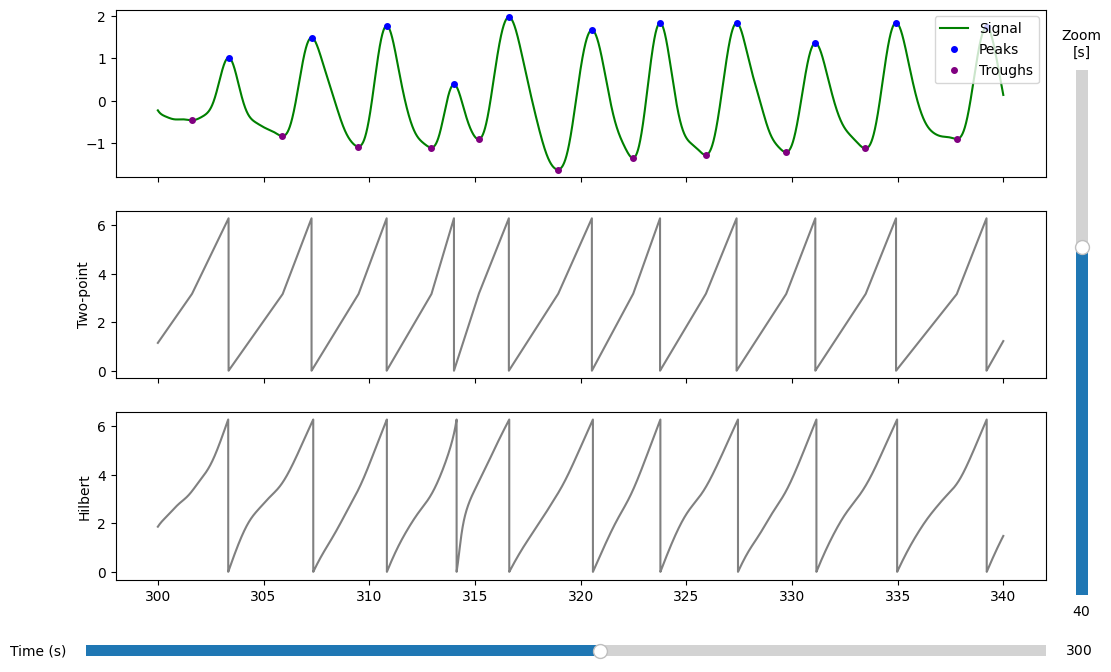

(<Figure size 1200x750 with 5 Axes>,
 array([<Axes: >, <Axes: ylabel='Two-point'>, <Axes: ylabel='Hilbert'>],
       dtype=object))

In [32]:
plot_phase_diagnostics(
    {"Two-point": PA_twopoint, "Hilbert": PA_hilbert},
    start = 300,
    window_duration = 40,
    fs = raw.fs,
    data = raw.ts,
    peaks=peaks_twopoint,
    troughs=troughs_twopoint
)

# Comparision

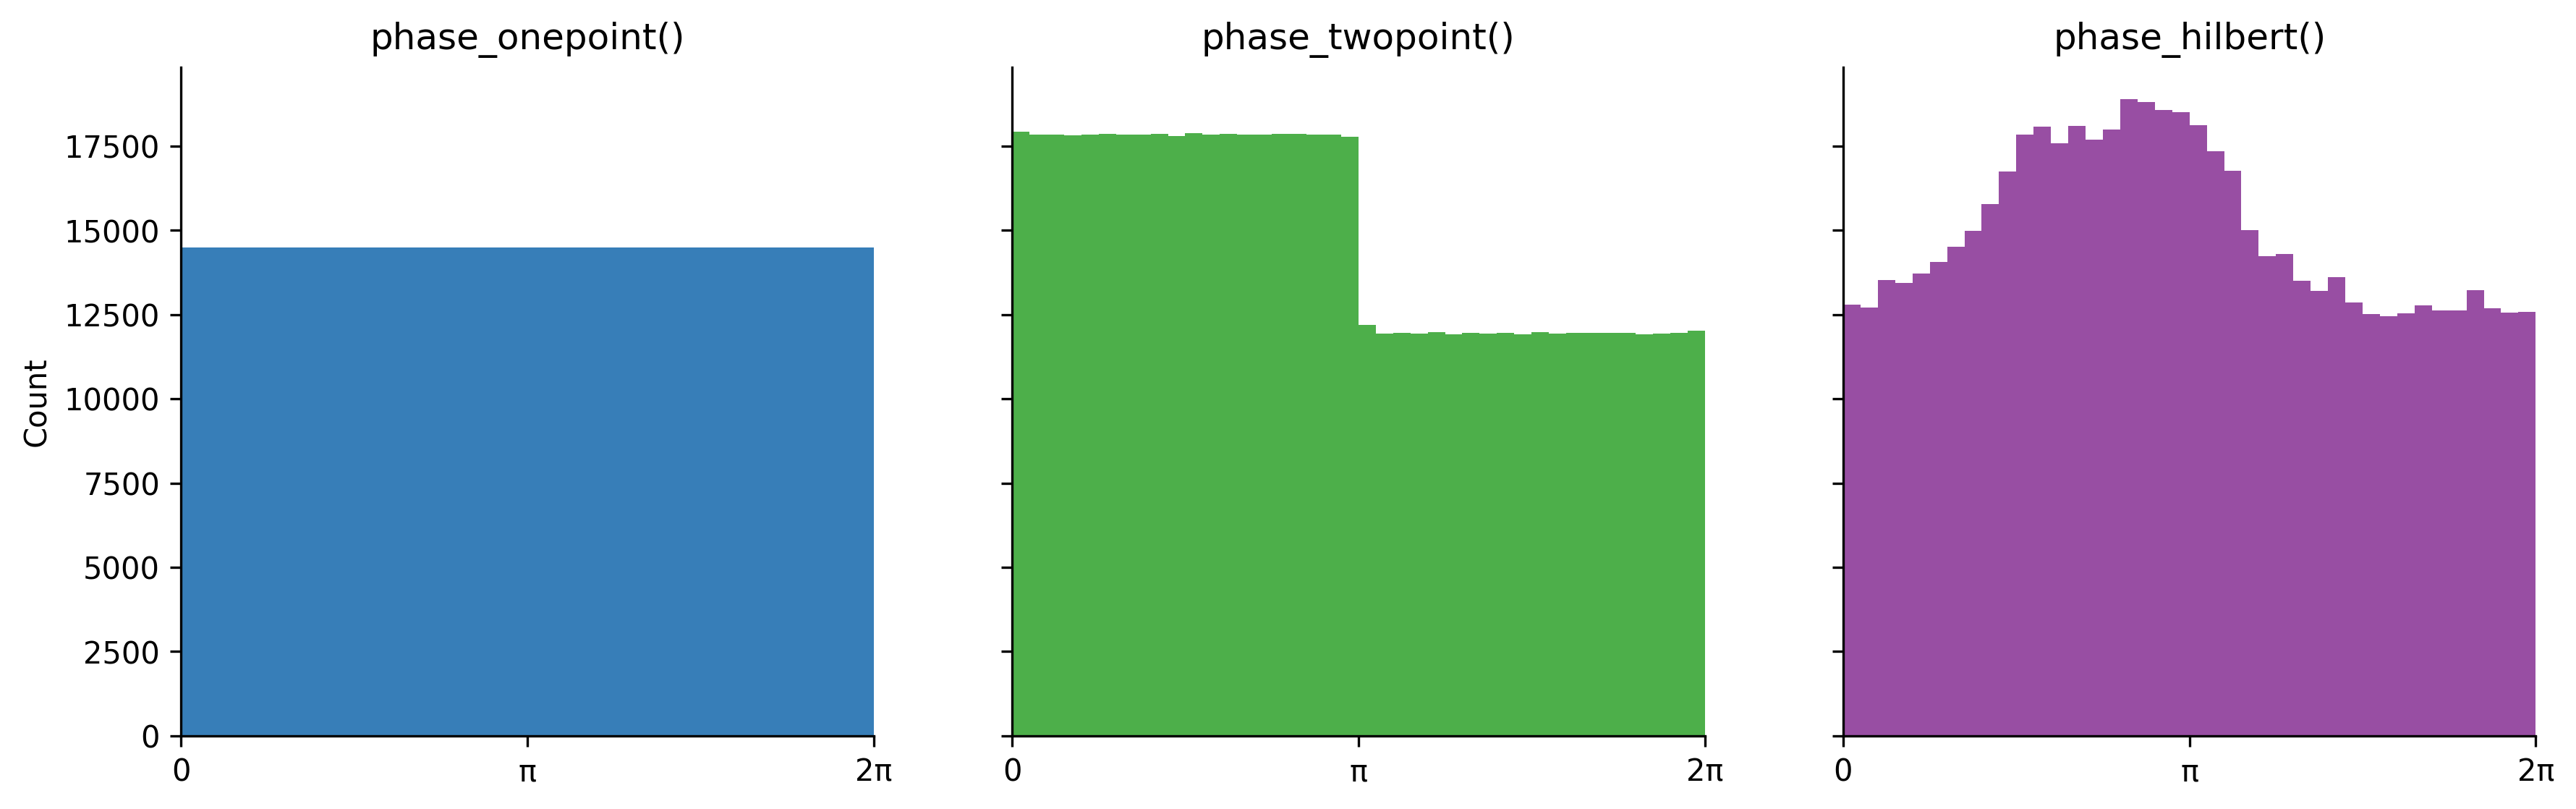

In [ ]:
# histogram of phase values
phase_values = [PA_onepoint, PA_twopoint, PA_hilbert]
labels = ['phase_onepoint()', 'phase_twopoint()', 'phase_hilbert()']

fig, axes = plt.subplots(1, len(phase_values), figsize=(14, 4), sharey=True, sharex=True, dpi=300)

cmap = plt.get_cmap('Set1')
colors = [cmap(i+1) for i in range(len(phase_values))]

for phase, label, ax, color in zip(phase_values, labels, axes, colors):

    ax.hist(phase, bins=40, color=color,)
    ax.set_title(label)
    ax.set_xlim(0, 2*np.pi)

axes[0].set_xticks([0, np.pi, 2*np.pi])
axes[0].set_xticklabels(['0', 'π', '2π'])
axes[0].set_ylabel('Count')

for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


In [63]:
# proportion of phase values in 0-pi and pi-2pi ranges
for phase, label in zip(phase_values, labels):
    prop_0_pi = np.sum((phase >= 0) & (phase < np.pi)) / len(phase)
    prop_pi_2pi = np.sum((phase >= np.pi) & (phase < 2*np.pi)) / len(phase)
    print(f"{label}: Proportion in [0, π): {prop_0_pi:.3f}, Proportion in [π, 2π): {prop_pi_2pi:.3f}")

phase_onepoint(): Proportion in [0, π): 0.483, Proportion in [π, 2π): 0.483
phase_twopoint(): Proportion in [0, π): 0.595, Proportion in [π, 2π): 0.399
phase_hilbert(): Proportion in [0, π): 0.541, Proportion in [π, 2π): 0.459
